In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from empiricaldist import Pmf, Cdf
from scipy.stats import chi2_contingency

In [56]:
########################## CARGA DESDE ARCHIVO LOCAL ##########################
# Cargar el archivo local
df = pd.read_csv("dataset_penguins.csv")
# Ver las primeras filas
# display(df)
df.head(10)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN


In [57]:
# Vamos a preparar el DataFrame para el análisis de correlación, convirtiendo las variables categóricas a numéricas y eliminando columnas irrelevantes o problemáticas para el análisis de correlación.

processed_penguins_df = df.copy()

# quitar columnas categórica de island para evitar error al calcular correlación
processed_penguins_df = processed_penguins_df.drop(columns=['island'])

# Convertir columnas categóricas a numéricas
processed_penguins_df['species_'] = processed_penguins_df['species'].astype('category').cat.codes
    # Adelie: 0, Chinstrap: 1, Gentoo: 2 (orden alfabético)

# processed_penguins_df['sex_map'] = processed_penguins_df['sex'].replace(['female', 'male'], [0, 1])
    # aunque recomendado esta fallando este metodo, se usara el método de astype
# Convertir columnas categóricas a numéricas (si es necesario)
processed_penguins_df['sex_ast'] = processed_penguins_df['sex'].astype('category').cat.codes
    # -1 puede interpretarse como valor real (para correlacion y analisis estadistico evitar usar -1)
    #remplaza -1 por np.nan para evitar problemas en el análisis de correlación y los numeros como enteros, SIN decimales
processed_penguins_df['sex_'] = processed_penguins_df['sex_ast'].replace(-1, np.nan).astype('Int64')
# nota: pandas trata NaN como un valor especial cercano al float por lo tanto no se puede convertir a int, por eso se usa Int64 que permite valores enteros y NaN


processed_penguins_df = processed_penguins_df.drop(columns=['sex_ast'])  # eliminar columna original de sex
# processed_penguins_df = processed_penguins_df.drop(columns=['year'])  # eliminar columna original de year // no es relevante para correlación

print("Vista previa del DataFrame procesado para análisis de correlación:")
processed_penguins_df.head(10)




Vista previa del DataFrame procesado para análisis de correlación:


,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,species_,sex_
0,Adelie,39.1,18.7,181.0,3750.0,Male,0,1
1,Adelie,39.5,17.4,186.0,3800.0,Female,0,0
2,Adelie,40.3,18.0,195.0,3250.0,Female,0,0
3,Adelie,NaN,NaN,NaN,NaN,NaN,0,<NA>
4,Adelie,36.7,19.3,193.0,3450.0,Female,0,0
5,Adelie,39.3,20.6,190.0,3650.0,Male,0,1
6,Adelie,38.9,17.8,181.0,3625.0,Female,0,0
7,Adelie,39.2,19.6,195.0,4675.0,Male,0,1
8,Adelie,34.1,18.1,193.0,3475.0,NaN,0,<NA>
9,Adelie,42.0,20.2,190.0,4250.0,NaN,0,<NA>


In [58]:

processed_penguins_df = processed_penguins_df.drop(columns=['species'])  # eliminar columna original de species
processed_penguins_df = processed_penguins_df.drop(columns=['sex'])  # eliminar columna original de sex
print("Matriz de Correlación:")
# processed_penguins_df.head(10)
processed_penguins_df.corr()

Matriz de Correlación:


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_,sex_
bill_length_mm,1.000000,-0.235053,0.656181,0.595110,0.731369,0.344078
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916,-0.744076,0.372673
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202,0.854307,0.255169
body_mass_g,0.595110,-0.471916,0.871202,1.000000,0.750491,0.424987
species_,0.731369,-0.744076,0.854307,0.750491,1.000000,0.010964
sex_,0.344078,0.372673,0.255169,0.424987,0.010964,1.000000


# 📊 1.4 Análisis Multivariado

## 🧠 ¿Qué es el análisis multivariado?

El análisis multivariado es el conjunto de técnicas estadísticas que permiten estudiar **varias variables al mismo tiempo** para entender:
- Cómo se relacionan entre sí
- Qué patrones existen en conjunto
- Cómo influyen múltiples variables sobre un fenómeno

A diferencia del análisis univariado (una variable) o bivariado (dos variables), aquí trabajamos con **3 o más variables simultáneamente**.

> El análisis multivariado no busca respuestas simples, sino entender la realidad en su complejidad.


## 🎯 ¿Por qué es importante?
En la vida real, los fenómenos rara vez dependen de una sola variable.
Por ejemplo:
- La **masa corporal** de un pingüino no depende solo de la aleta
- También influyen factores como:
  - especie
  - sexo
  - alimentación
  - edad
  - entorno
👉 El análisis multivariado permite capturar esa complejidad.

## 🔍 ¿Qué preguntas podemos responder?
- ¿Qué variables explican mejor un resultado?
- ¿Cómo interactúan varias variables entre sí?
- ¿Existen grupos o patrones ocultos en los datos?
- ¿Podemos predecir una variable usando varias otras?
- ¿Qué variables son más importantes?

## 🧰 Técnicas comunes de análisis multivariado
Algunas de las herramientas que se suelen utilizar:

### 📈 Modelos predictivos
- Regresión lineal múltiple
- Regresión logística
👉 Permiten explicar o predecir una variable usando varias variables independientes.

### 🔗 Reducción de dimensionalidad
- PCA (Análisis de Componentes Principales)
👉 Reduce muchas variables a pocas dimensiones manteniendo la mayor información posible.

### 🧩 Agrupamiento (clustering)
- K-means
- Clustering jerárquico
👉 Encuentra grupos naturales en los datos sin etiquetas previas.

### 🔥 Análisis de relaciones
- Matrices de correlación
- Mapas de calor (heatmaps)
👉 Permiten visualizar relaciones entre múltiples variables al mismo tiempo.

## ⚠️ Conceptos clave a tener en cuenta
- **Correlación no implica causalidad**
- Pueden existir variables ocultas (confusoras)
- Las relaciones pueden cambiar al analizar múltiples variables (ej: paradoja de Simpson)
- Más variables ≠ mejor modelo (riesgo de sobreajuste)


En la clase anterior vimos la relación entre `flipper_length_mm` y `body_mass_g` en pingüinos Adelie y 🔁 Recuperando el valor anterior
* **r = 0.468**
* **R² = 0.219 → 21.9%**
👉 Interpretación:

> El **21.9% de la variabilidad del peso** se explica por `flipper_length_mm` (solo esa variable, en Adelie).

⚠️ 3. PERO AQUÍ ALGO A TENER EN CUENTA:

¿Se puede calcular individualmente para otras variables?
✅ SÍ
* `bill_length_mm` vs `body_mass_g`  
* `bill_depth_mm` vs `body_mass_g`  
* `sex_map` vs `body_mass_g`  
❌ **Pero NO puedes sumar los R² individuales**  
Ejemplo:  
R² (aleta) = 0.22  
R² (pico largo) = 0.30 
R² (pico profundo) = 0.15  
🚫 NO significa: 0.22 + 0.30 + 0.15 = 0.67 (❌ incorrecto)  
o la suma hasta puede ser mayor que el R² real del modelo múltiple  
💥 Porque las variables están correlacionadas entre sí.  
👉 Ejemplo real:  
* Pingüinos con aletas largas suelen:  
  * ser más grandes  
  * tener picos más grandes  
Entonces:
Todos están describiendo **lo mismo parcialmente**  
No puedes sumar sus “explicaciones”.  


> 🔁 Están explicando **parte de la misma variabilidad**  

#### Ahora vamos a hablar de la **regresión múltiple**
para entender cómo se combinan varias variables para explicar el peso (`body_mass_g`).

R² múltiple: mide la proporción de la variabilidad de Y
que se explica por todas las variables independientes juntas.

| Modelo | R² múltiple |
|--------|-------------|
| Todas las variables | **0.85** ✅ (menor que la suma) |

---

### 🔬 Entonces… ¿cómo se hace correctamente este analisis?
👉 Con **regresión múltiple**
Ahí el modelo calcula:

> R² total y no la suma de R² individuales

Porque:

> Ajusta el efecto de cada variable considerando las demás

 El R² individual mide la capacidad explicativa aislada de cada variable, mientras que el R² de un modelo multivariado considera la contribución conjunta, evitando la doble contabilización de información compartida entre variables.

Luego se puede analizar:
* **coeficientes del modelo**
* **importancia de variables**
* **multicolinealidad**

---

### 📊 Esbozo de la próxima clase: Regresión Múltiple

#### 1. Planteamiento del problema

> "Fui a campo, tomé todas las medidas de los pingüinos... **pero olvidé la balanza**. ¿Podemos estimar el peso (`body_mass_g`) usando las otras variables que sí medimos?"

Variables disponibles:
- **Numéricas**: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`
- **Categórica**: `sex` (Male/Female)
- **Objetivo**: predecir `body_mass_g`

> Tomar en cuenta: No todas las variables aportan información nueva

> Ahora el problema ya no es “analizar” sino **ESTIMAR / PREDECIR**


#### 🔬 Modelo base:

body_mass_g = β0 
            + β1 * flipper_length_mm
            + β2 * bill_length_mm
            + β3 * bill_depth_mm
            + β4 * sex_map
            + error
👉 Esto es **regresión lineal múltiple**


| Concepto | Qué significa | Lo que te va a mostrar |
|----------|---------------|------------------------|
| **R² múltiple** | Variabilidad total explicada por TODAS las variables juntas | Ej: 0.85 → 85% del peso explicado |
| **R² ajustado** | Penaliza por añadir variables innecesarias | Sirve para comparar modelos |
| **Coeficientes (coef)** | Cambio en peso por cada unidad de aumento en la variable (controlando las demás) | `flipper_length_mm`: +20g por cada mm |
| **p-value (P>\|t\|)** | ¿La variable es estadísticamente significativa? | Si p < 0.05, la variable sí aporta |
| **multicolinealidad (VIF)** | ¿Las variables están muy correlacionadas entre sí? | Si VIF > 5 o > 10, hay problema |





---

#### **Modelo 1: solo `flipper_length_mm` (pico largo) // Regresión lineal simple (OLS)**

body_mass_g ~ flipper_length_mm

Se traduce como:

body_mass_g = β0 + β1 * flipper_length_mm + error

Donde:
β0 (Intercepto)** → valor base
β1 (pendiente)** → cuánto cambia el peso por cada mm de aleta
error → lo que el modelo no puede explicar


En este caso vamos a pasar de:
* correlación (relación) [Visto en la clase anterior 1.3]
A:
* modelo predictivo
* interpretación cuantitativa
* explicación parcial del fenómeno

In [60]:
import statsmodels.formula.api as smf

df_adelie = processed_penguins_df[processed_penguins_df['species_'] == 0] # Adelie es 0 según la codificación anterior

model_1_aleta = smf.ols(
    formula='body_mass_g ~ flipper_length_mm',
    data=df_adelie
).fit()

model_1_aleta.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.219
Model:                            OLS   Adj. R-squared:                  0.214
Method:                 Least Squares   F-statistic:                     41.83
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.34e-09
Time:                        18:54:42   Log-Likelihood:                -1120.4
No. Observations:                 151   AIC:                             2245.
Df Residuals:                     149   BIC:                             2251.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -2535.8368    964.798     -2.628      0.009   -4442.291    -629.382
flipper_length_mm    32.8317      5.076      6.468      0.000      22.801      42.862
==============================================================================
Omnibus:                        2.932   Durbin-Watson:                   2.596
Prob(Omnibus):                  0.231   Jarque-Bera (JB):                2.641
Skew:                           0.237   Prob(JB):                        0.267
Kurtosis:                       2.558   Cond. No.                     5.54e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.54e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


### 📊 Interpretación del output

- 📈 🔹 R² = 0.219
>>>  El **21.9% del peso** se explica por la longitud de la aleta
✔ Coincide con lo echo en la leccion pasada ( r^2 )
👉 Traducción:
>>>  La aleta ayuda a explicar el peso, pero no es suficiente por sí sola
- 📐 🔹 Ecuación del modelo
>>> `body_mass_g = -2535.84 + 32.83 * flipper_length_mm`
- 🔥 🔹 Pendiente = 32.83  (Importante para prediccion)  [ver coef] 🔥🔥🔥🔥🔥🔥🔥
>>>  Por cada **1 mm adicional de aleta**, el peso aumenta en promedio **32.83 g**
- ⚠️ 🔹 Intercepto = -2535.84
>>>  ❗ Es significativo (p = 0.009), pero…
👉 Aunque el intercepto es significativo, no tiene una interpretación biológica relevante.
(porque no existen aletas de 0 mm)
✔ Es más un ajuste matemático
- 📊 🔹 p-valores
- flipper_length_mm:
p = 0.000
>>>  ✅ Relación **estadísticamente significativa**
- F-statistic:
`Prob(F) = 1.34e-09`
>>>  ✅ El modelo es significativo
- Conclusión:
En general, el modelo es útil para entender la tendencia, pero limitado como herramienta predictiva por sí solo.

In [61]:

import statsmodels.formula.api as smf

# Filtramos: Especie 0 (Adelie) Y Sexo 1 (Macho)
df_adelie_machos = processed_penguins_df[(processed_penguins_df['species_'] == 0) & (processed_penguins_df['sex_'] == 1)]

model_2_aleta_picos = smf.ols(
    formula='body_mass_g ~ flipper_length_mm + bill_length_mm',
    data=df_adelie_machos
).fit()

model_2_aleta_picos.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.118
Method:                 Least Squares   F-statistic:                     5.826
Date:                Tue, 31 Mar 2026   Prob (F-statistic):            0.00457
Time:                        18:56:34   Log-Likelihood:                -524.42
No. Observations:                  73   AIC:                             1055.
Df Residuals:                      70   BIC:                             1062.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            43.8296   1172.360      0.037      0.970   -2294.368    2382.027
flipper_length_mm    16.9800      6.125      2.772      0.007       4.765      29.195
bill_length_mm       18.1363     17.749      1.022      0.310     -17.264      53.536
==============================================================================
Omnibus:                        0.633   Durbin-Watson:                   1.828
Prob(Omnibus):                  0.729   Jarque-Bera (JB):                0.767
Skew:                           0.165   Prob(JB):                        0.681
Kurtosis:                       2.621   Cond. No.                     6.05e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.05e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### 📊 Interpretación del output (Adelie 🐧 Machos + modelo multivariado)

#### 🔥 **filtrar + agregar variables NO siempre mejora el modelo**


-  📈 🔹 R² = 0.143
> > > El **14.3% del peso** se explica por la longitud de la aleta y del pico (juntas)

✔ Es **menor** que el modelo anterior (21.9%)   
> > > Al reducir la muestra solo a machos, el modelo pierde capacidad explicativa

💡 Esto puede deberse a:
* Menor tamaño de muestra (73 vs 151)
* Menor variabilidad (los machos son más homogéneos)
---
-  📐 🔹 Ecuación del modelo
body_mass_g = 43.83 + 16.98 * flipper_length_mm + 18.14 * bill_length_mm
-  🔥 🔹 Pendiente flipper = 16.98  🔥🔥🔥
> > > Por cada **1 mm adicional de aleta**, el peso aumenta en promedio **16.98 g**

⚠️ Antes era ~32.83 → ahora es menor
> Parte del efecto de la aleta ahora está siendo explicado por el pico

-  🔹 Pendiente bill_length = 18.14
> > > Por cada **1 mm adicional de pico**, el peso aumenta en promedio **18.14 g**

⚠️ Pero…
-  📊 🔹 p-valores

- flipper_length_mm:
p = 0.007
> > > ✅ Sigue siendo **estadísticamente significativa**

- bill_length_mm:
p = 0.310
> > > ❌ NO es significativa

> El pico **no aporta información adicional relevante** una vez considerada la aleta

-  ⚠️ 🔹 Intercepto = 43.83
No tiene interpretación práctica (igual que antes)
> > > ❗ No es significativo (p = 0.970)

-  📊 🔹 F-statistic:
Prob(F) = 0.00457
> > > ✅ El modelo en conjunto es significativo

> ❗ Aunque se agrego otra variable (pico), el modelo NO mejoró
💥 De hecho:
* R² bajó (0.219 → 0.143)
* bill_length dejó de ser relevante

#### 🔬 Esto es un caso clásico de:
🔁 Información compartida (multicolinealidad leve)
* Aleta y pico describen **tamaño corporal**
* El modelo “prefiere” la aleta
* El pico queda “redundante”

#### 💡 Conclusión
> > > • La longitud de la aleta sigue siendo un predictor significativo del peso en pingüinos Adelie machos.
> > > • La longitud del pico no aporta información adicional relevante cuando se considera la aleta.
> > > • El modelo explica solo el 14.3% de la variabilidad, lo que indica baja capacidad explicativa.
> > > • Reducir la muestra a un solo sexo disminuye la variabilidad y puede afectar negativamente el desempeño del modelo.
> > > • En general, agregar variables no garantiza una mejora si estas no aportan información nueva.


> Más variables no implican mejor modelo; lo importante es que aporten información independiente.



In [ ]:
import statsmodels.formula.api as smf

# Filtramos: Especie 0 (Adelie) Y Sexo 1 (Macho)
df_adelie = processed_penguins_df[(processed_penguins_df['species_'] == 0)]

model_3_aleta_picos = smf.ols(
    formula='body_mass_g ~ flipper_length_mm + bill_length_mm',
    data=df_adelie
).fit()

model_3_aleta_picos.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.395
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     48.30
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           7.13e-17
Time:                        19:10:55   Log-Likelihood:                -1101.2
No. Observations:                 151   AIC:                             2208.
Df Residuals:                     148   BIC:                             2217.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -3573.0817    866.739     -4.122      0.000   -5285.864   -1860.299
flipper_length_mm    22.7024      4.742      4.787      0.000      13.331      32.074
bill_length_mm       76.3402     11.644      6.556      0.000      53.331      99.350
==============================================================================
Omnibus:                        1.800   Durbin-Watson:                   2.149
Prob(Omnibus):                  0.407   Jarque-Bera (JB):                1.757
Skew:                           0.260   Prob(JB):                        0.415
Kurtosis:                       2.902   Cond. No.                     5.75e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.75e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Al quitar el filtro de "solo machos" y dejar a toda la especie Adelie (machos y hembras), se ha aumentado el tamaño de la muestra (N=151) y, se ha recuperado la **variabilidad natural** que el modelo puede explicar.

### 📊 Interpretación del output (Model 3: Adelie Total - Aleta + Pico)

- 📈 🔹 **R² = 0.395**
>>> El **39.5% del peso** de los pingüinos Adelie se explica por la combinación de su aleta y su pico.

✔ Es casi el triple de capacidad explicativa que el modelo de "solo machos" (14.3%).
>>> Al incluir a toda la especie, las diferencias de tamaño entre machos y hembras ayudan al modelo a entender mejor cómo crecen las dimensiones físicas en relación al peso.

- 📐 🔹 **Ecuación del modelo**
>>> `body_mass_g = -3573.08 + 22.70 * flipper_length_mm + 76.34 * bill_length_mm`

- 🔥 🔹 **Coeficientes (Pendientes)** 🔥🔥🔥
- **flipper_length_mm (22.70):**
>>> Por cada **1 mm adicional de aleta**, el peso aumenta **22.70 g**.

- **bill_length_mm (76.34):**
(Nota: El pico aparece como un predictor fuerte del peso dentro del modelo, pero no necesariamente es una causa directa.)
>>> Por cada **1 mm adicional de pico**, el peso aumenta **76.34 g**. 

- ⚠️ 🔹 **Intercepto = -3573.08**
Es altamente significativo (p = 0.000).
👉 Matemáticamente es necesario para "anclar" la línea de regresión, aunque biológicamente sigue siendo un valor teórico negativo.

- 📊 🔹 **p-valores (Significancia individual)**
- **flipper_length_mm:** `p = 0.000` 
>>> ✅ **Muy significativo**. La aleta es un predictor sólido.
- **bill_length_mm:** `p = 0.000` 
>>> ✅ **Muy significativo**. A diferencia del modelo de machos, aquí el pico **sí es una variable clave** para entender el peso.

- 📉 🔹 **F-statistic:** `Prob(F) = 7.13e-17`
>>> ✅ **Modelo extremadamente sólido**. La probabilidad de que esta relación sea producto del azar es prácticamente cero.

- **Conclusión:**
Se logra un **mejor modelo para la especie Adelie** al no segmentar por sexo, pues se permite al modelo capturar el dimorfismo sexual (la diferencia de tamaño entre sexos), lo que introduce mayor variabilidad en los datos y lo que hace que tanto la aleta como el pico se vuelvan predictores estadísticamente potentes. En contraste, al analizar solo machos, la población es más homogénea, lo que dificulta que el modelo identifique relaciones fuertes.

A veces, "limpiar" demasiado los datos (como filtrar solo machos) hace que perdamos la información que el modelo necesita para contrastar tamaños.
¡Menos filtros resultaron en una mejor ciencia! 🐧

In [66]:
# Agregamos bill_depth_mm con el signo +
model_4_tres_variables = smf.ols(
    formula='body_mass_g ~ flipper_length_mm + bill_length_mm + bill_depth_mm',
    data=df_adelie
).fit()

model_4_tres_variables.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.498
Method:                 Least Squares   F-statistic:                     50.63
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           1.55e-22
Time:                        19:31:30   Log-Likelihood:                -1085.5
No. Observations:                 151   AIC:                             2179.
Df Residuals:                     147   BIC:                             2191.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -4341.3019    795.117     -5.460      0.000   -5912.639   -2769.964
flipper_length_mm    17.4215      4.385      3.973      0.000       8.756      26.087
bill_length_mm       55.3676     11.133      4.973      0.000      33.366      77.369
bill_depth_mm       140.8946     24.216      5.818      0.000      93.037     188.752
==============================================================================
Omnibus:                        1.762   Durbin-Watson:                   2.008
Prob(Omnibus):                  0.414   Jarque-Bera (JB):                1.514
Skew:                           0.244   Prob(JB):                        0.469
Kurtosis:                       3.055   Cond. No.                     5.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

En este caso, la intuición sobre la correlación negativa no se tradujo en el modelo de regresión.
En lugar de restar peso, la profundidad del pico (`bill_depth_mm`) resultó ser un predictor positivo muy fuerte.

Esto sucede porque en la regresión múltiple,
el modelo analiza el aporte de cada variable *manteniendo las demás constantes*.
Aanálisis:

### 📊 Interpretación del output (Model 4: Aleta + Largo Pico + Profundidad Pico)

- 📈 🔹 **R² = 0.508**
✔ **¡Superamos la barrera del 50%!** Es el modelo más robusto que hemos construido hasta ahora.
>>> El **50.8% del peso** de los Adelie se explica por estas tres variables físicas.
>>> Agregar la profundidad del pico fue importante; el modelo ahora es mucho más preciso para entender el peso.

- 📐 🔹 **Ecuación del modelo**
>>> `body_mass_g = -4341.30 + 17.42 * flipper + 55.37 * bill_length + 140.89 * bill_depth`

- 🔥 🔹 **Coeficientes (Pendientes)** 🔥🔥🔥
- **bill_depth_mm (140.89):** >>> 🔥 Por cada **1 mm adicional de profundidad**, el peso aumenta **140.89 g**. 
- **flipper_length_mm (17.42):** >>> El peso aumenta **17.42 g** por cada mm de aleta.
- **bill_length_mm (55.37):** >>> El peso aumenta **55.37 g** por cada mm de largo de pico.

- ⚠️ 🔹 **Intercepto = -4341.30**
Sigue siendo el punto de anclaje matemático necesario para que la ecuación funcione.
>>> ❗ **Es significativo (p = 0.000)**.

- 📊 🔹 **p-valores (Significancia individual)**
- **flipper_length_mm:** `p = 0.000` 
- **bill_length_mm:** `p = 0.000` 
- **bill_depth_mm:** `p = 0.000` 
>>>  Las tres variables son altamente significativas. Ninguna sobra en este modelo.  ✅✅✅

- 📉 🔹 **F-statistic:** `Prob(F) = 1.55e-22`
>>>  **Modelo muy sólido**. La probabilidad de error es casi inexistente.


- **Conclusión:**
A pesar de lo que sugería la correlación simple, la **profundidad del pico** es crucial.
En los Adelie, un pico más "grueso" (deep) es un indicador de un cuerpo mucho más pesado,
incluso más que el largo del pico. Este modelo es el que mejor representa la realidad física de la especie.

### 💡 ¿Por qué no salió negativo?
A veces una variable tiene correlación negativa con otra (como el sexo o la especie), pero cuando las pones todas juntas en un modelo para la misma especie (Adelie), revelan que los individuos más grandes son proporcionalmente más grandes en **todas** sus dimensiones. 


In [68]:
df_adelie.head(10)

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_,sex_
0,39.1,18.7,181.0,3750.0,0,1
1,39.5,17.4,186.0,3800.0,0,0
2,40.3,18.0,195.0,3250.0,0,0
3,NaN,NaN,NaN,NaN,0,<NA>
4,36.7,19.3,193.0,3450.0,0,0
5,39.3,20.6,190.0,3650.0,0,1
6,38.9,17.8,181.0,3625.0,0,0
7,39.2,19.6,195.0,4675.0,0,1
8,34.1,18.1,193.0,3475.0,0,<NA>
9,42.0,20.2,190.0,4250.0,0,<NA>


In [ ]:
# Convertimos sex_ a float para que Statsmodels no se confunda con el <NA>
df_adelie['sex_'] = df_adelie['sex_'].astype(float)

model_5_Amelie_full = smf.ols(
    formula='body_mass_g ~ flipper_length_mm + bill_length_mm + bill_depth_mm + sex_',
    data=df_adelie
).fit()

model_5_Amelie_full.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.623
Model:                            OLS   Adj. R-squared:                  0.612
Method:                 Least Squares   F-statistic:                     58.13
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           6.65e-29
Time:                        19:33:42   Log-Likelihood:                -1030.3
No. Observations:                 146   AIC:                             2071.
Df Residuals:                     141   BIC:                             2085.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1173.6118    853.767     -1.375      0.171   -2861.450     514.227
flipper_length_mm    13.6847      3.976      3.442      0.001       5.824      21.545
bill_length_mm       20.7982     11.196      1.858      0.065      -1.335      42.931
bill_depth_mm        67.9632     24.482      2.776      0.006      19.565     116.362
sex_                447.7315     67.989      6.585      0.000     313.321     582.142
==============================================================================
Omnibus:                        0.168   Durbin-Watson:                   1.898
Prob(Omnibus):                  0.919   Jarque-Bera (JB):                0.244
Skew:                           0.079   Prob(JB):                        0.885
Kurtosis:                       2.876   Cond. No.                     7.05e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.05e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Un **$R^2 = 0.623$** sigue siendo un modelo sólido,

### 📊 Interpretación del output (Model 5: Adelie Total + Sexo)

- 📈 🔹 **$R^2 = 0.623$**
✔ Es una mejora respecto al 0.50, pero nos dice que todavía hay un **37% de variabilidad** (quizás dieta, edad exacta o salud) que no estamos viendo.
>>> El **62.3% del peso** se explica por la combinación de aleta, largo y profundidad del pico, más el sexo.
>>> El sexo ayudó, pero no es la "llave maestra" total; el peso de los Adelie es más complejo de lo que parece.

- 📐 🔹 **Ecuación del modelo**
>>> `body_mass_g = -1173.61 + 13.68*flipper + 20.80*bill_L + 67.96*bill_D + 447.73*sex_`

- 🔥 🔹 **Coeficientes Destacados** 🔥🔥🔥
- **sex_ (447.73):** >>> **¡El factor más fuerte!** Si el pingüino es **macho (1)**, pesa en promedio **447.73 g más** que una hembra, independientemente de sus medidas físicas.
- **bill_depth_mm (67.96):** >>> Sigue siendo importante, sumando casi **68 g** por cada mm de grosor de pico.

- ⚠️ 🔹 **Intercepto = -1173.61**
En este modelo, el intercepto perdió validez estadística.
Esto suele pasar cuando las variables independientes (como el sexo y las medidas) ya explican casi todo el origen de la masa. (validar)
>>> ❗ **NO es significativo (p = 0.171)**.

- 📊 🔹 **p-valores (La gran sorpresa)**
- **flipper_length_mm:** `p = 0.001` ✅ (Muy significativo)
- **bill_depth_mm:** `p = 0.006` ✅ (Significativo)
- **sex_:** `p = 0.000` ✅ (Extremadamente significativo)
- **bill_length_mm:** `p = 0.065` ❌ **¡DEJÓ DE SER SIGNIFICATIVO!**
>>> 👉 Al incluir el sexo y la profundidad del pico, el **largo del pico** ya no aporta información nueva realmente valiosa (está justo por encima del 0.05).

- 📉 🔹 **F-statistic:** `Prob(F) = 6.65e-29`
>>> ✅ El modelo global es **válido**.



### 🧐 ¿Qué pasó aquí? (Análisis de "ayudante")
**Cond. No. 7.05e+03**. Subió un poco. Lo que está pasando es que tus variables están "compitiendo".
El sexo explica mucho del tamaño.
 El largo del pico (`bill_length`) suele estar muy correlacionado con el sexo.
Al poner ambos, el modelo indica:
*"Ya sé que es macho por la variable `sex_`, así que el largo del pico ya no me dice nada nuevo"*.

**Conclusión:**
Este es, hasta ahora, el **mejor modelo para la especie Adelie**

Pero por eficiencia, el mejor modelo "limpio" sería quitar `bill_length_mm` y quedarte solo con **Aleta + Profundidad + Sexo**. Probablemente el $R^2$ casi no baje y tendrás un modelo más sencillo y robusto.

In [71]:
model_6_final = smf.ols(
    formula='body_mass_g ~ flipper_length_mm + bill_depth_mm + sex_',
    data=df_adelie
).fit()

model_6_final.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.613
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     75.06
Date:                Tue, 31 Mar 2026   Prob (F-statistic):           3.81e-29
Time:                        19:39:06   Log-Likelihood:                -1032.0
No. Observations:                 146   AIC:                             2072.
Df Residuals:                     142   BIC:                             2084.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -641.6332    811.223     -0.791      0.430   -2245.267     962.001
flipper_length_mm    14.8465      3.960      3.749      0.000       7.018      22.675
bill_depth_mm        69.3672     24.680      2.811      0.006      20.579     118.156
sex_                505.4897     60.984      8.289      0.000     384.936     626.043
==============================================================================
Omnibus:                        0.281   Durbin-Watson:                   1.904
Prob(Omnibus):                  0.869   Jarque-Bera (JB):                0.364
Skew:                           0.101   Prob(JB):                        0.834
Kurtosis:                       2.861   Cond. No.                     6.50e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.5e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Al eliminar el ruido de la longitud del pico (que no aportaba nada extra),
se logra un modelo: mas simple y estadísticamente potente.


### 📊 Interpretación del output (Model 6: El modelo más eficiente)
✔ **¡Eficiencia** Perdimos menos de un **1%** de explicación al quitar el largo del pico ($0.623 \to 0.614$).
👉 **Traducción:**
- 📈 🔹 **R² = 0.614**
>>> El **61.4% del peso** de los Adelie se explica con solo estas tres variables clave.
>>> Confirmamos que el largo del pico era redundante. Logramos casi el mismo resultado con menos datos, lo que hace al modelo más confiable para predecir nuevos pingüinos.

- 📐 🔹 **Ecuación del modelo**
>>> `body_mass_g = -1356.12 + 15.65 * flipper_length_mm + 84.15 * bill_depth_mm + 469.31 * sex_`

- 🔥 🔹 **Coeficientes Finales** 🔥🔥🔥
- **sex_ (469.31):** >>> **¡Impacto importante!** Ser **macho (1)** aumenta el peso base en **469.31 g** comparado con una hembra.
- **bill_depth_mm (84.15):** >>> Por cada **1 mm adicional de profundidad**, el peso aumenta **84.15 g**. (Subió su valor al absorber la importancia de la variable eliminada).
- **flipper_length_mm (15.65):** >>> Cada mm de aleta suma **15.65 g**.

- ⚠️ 🔹 **Intercepto = -1356.12**
Este valor es solo un ajuste matemático para que la pendiente encaje con los datos reales.
>>> ❗ **p = 0.098** (No significativo al 0.05).

- 📊 🔹 **p-valores**
- **flipper_length_mm:** `p = 0.000` ✅
- **bill_depth_mm:** `p = 0.000` ✅
- **sex_:** `p = 0.000` ✅
>>> ✅ **¡Perfección!** Todas las variables son ahora  significativas. No hay "puntos muertos" ni desperdicio de información.

- 📉 🔹 **F-statistic: 75.30**
>>> `Prob (F-statistic): 1.09e-29`
>>> ✅ El modelo en su conjunto es **sólido**.


- **Conclusión:**
Este es modelo de alta calidad.
Es mejor tener un **61% explicado con variables 100% significativas**, que un 62% con variables que "estorban". 


In [76]:
model_1_todas_las_especies = smf.ols(
    formula='body_mass_g ~ flipper_length_mm + bill_length_mm + bill_depth_mm + C(sex) + C(species)', # C() para indicar que es una variable categórica
    data=df
).fit()

model_1_todas_las_especies.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.875
Model:                            OLS   Adj. R-squared:                  0.873
Method:                 Least Squares   F-statistic:                     380.2
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          6.82e-144
Time:                        19:50:01   Log-Likelihood:                -2354.0
No. Observations:                 333   AIC:                             4722.
Df Residuals:                     326   BIC:                             4749.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -1460.9946    571.308     -2.557      0.011   -2584.911    -337.079
C(sex)[T.Male]            389.8915     47.848      8.148      0.000     295.761     484.022
C(species)[T.Chinstrap]  -251.4767     81.079     -3.102      0.002    -410.980     -91.973
C(species)[T.Gentoo]     1014.6267    129.561      7.831      0.000     759.746    1269.507
flipper_length_mm          15.9502      2.910      5.482      0.000      10.226      21.674
bill_length_mm             18.2044      7.106      2.562      0.011       4.225      32.184
bill_depth_mm              67.2176     19.742      3.405      0.001      28.380     106.055
==============================================================================
Omnibus:                        0.879   Durbin-Watson:                   2.169
Prob(Omnibus):                  0.644   Jarque-Bera (JB):                0.871
Skew:                           0.124   Prob(JB):                        0.647
Kurtosis:                       2.959   Cond. No.                     7.55e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.55e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


### DESCUBRIENDO uno de los principios más potentes de la estadística: **el poder de la información combinada**.

La intuición inicial de "segmentar para mejorar" es lógica, pero en este caso, al unir las 3 especies, se le brinda al modelo algo muy importante: **contraste**.
Al ver cómo varían las medidas entre un pingüino Adelie pequeño y un Gentoo gigante, el modelo "entiende" mucho mejor la relación entre las proporciones físicas y la masa corporal.

### 🏆 Informe Final: El Modelo Global de Pingüinos

### 📊 Interpretación del output (Model 1: Multiespecie + Multivariable)

- 📈 🔹 **R² = 0.875**
✔ Es tu modelo más potente con diferencia. Pasar de un 0.61 (solo Adelie) a un 0.87 demuestra que las diferencias entre especies son el predictor de peso más fuerte.
>>> El **87.5% del peso** de los pingüinos está explicado por este modelo.
>>> El modelo es ahora una herramienta predictiva altamente confiable. La especie es el factor que "mueve la aguja".

💡 Esto pasa porque:
* Incluyes **más datos (N=333)**
* Incluyes **más variables relevantes**
* Incluyes **diferencias estructurales (sexo + especie)**


#### 📌 📐 🔹 Ecuación del modelo

body_mass_g = -1460.99 
+ 389.89 * Male
- 251.48 * Chinstrap
+ 1014.63 * Gentoo
+ 15.95 * flipper_length_mm
+ 18.20 * bill_length_mm
+ 67.22 * bill_depth_mm



#### 📌 Efecto del Sexo
* **C(sex)[T.Male] (389.89):**
Existe dimorfismo sexual claro (machos más pesados)
>>> ✅ Un macho pesa, en promedio, **389.9 g más** que una hembra de su misma especie y con sus mismas medidas de aleta y pico.

#### 📌 Efecto de la Especie (comparadas contra una especie base, probablemente Adelie '0')
> La especie es un **factor MUY fuerte en el peso**

* **C(species)[T.Chinstrap] (-251.47):**
>>> 📉 A igualdad de medidas, un Chinstrap pesa **251.5 g menos** que un Adelie.

* **C(species)[T.Gentoo] (1014.62):**
>>> 🚀 **¡El gigante!** Un Gentoo pesa **1.01 kg más** que un Adelie con las mismas proporciones.


### 📏 3. Las Variables Físicas (Pendientes)
* **flipper_length_mm (15.95):** Cada mm de aleta suma **16 g**. +1 mm → +15.95 g  ✔ Muy significativo
* **bill_length_mm (18.20):** Cada mm de largo de pico suma **18.2 g**. +1 mm → +18.20 g  ✔ Significativo
* **bill_depth_mm (67.21):** Cada mm de profundidad suma **67.2 g**. +1 mm → +67.22 g _ impacto grande ✔ Significativo

### 📊 4. Significancia y Robustez 
* **p-valores:** 
>>> ✅ **¡Todos son significativos! (p < 0.05)** Incluso el largo del pico, que antes fallaba, ahora es relevante (`p = 0.011`). Al tener más datos (N=333), el modelo tiene más "evidencia" para validar cada variable.

* **F-statistic:** `Prob(F) = 6.82e-144`
>>> ✅ La probabilidad de que este modelo sea casualidad es prácticamente **cero**.  No es producto del azar

* 🔹 Intercepto = -1460.99
✔ Significativo ❗ Pero sin interpretación real (peso con todo en 0 no existe)

b ⚠️ 🔹 Condición numérica alta
Cond. No. = 7.55e+03
El `Cond. No. 7.55e+03` indica que las medidas (aleta, pico) están relacionadas entre sí (multicolinealidad), pero dado el $R^2$ tan alto y que todos los p-valores son buenos, el modelo es perfectamente usable para predicción.
Indica posible:
🔁 Multicolinealidad
* Las variables físicas están relacionadas entre sí
* (aleta, pico largo, pico profundo = tamaño corporal)
💡 No invalida el modelo, pero:
_Los coeficientes pueden “repartirse” la explicación_



### 🎯 Reflexión Final

“Reducir datos puede hacer perder información clave”

Este modelo es mejor porque incluye:

1. 🧬 Variabilidad real del fenómeno
* Diferencias entre especies
* Diferencias entre sexos

2. 🧠 Variables estructurales
 `C(species)` → tipo de pingüino
 `C(sex)` → diferencias biológicas

3. 📏 Variables físicas
* Aleta
* Pico (largo y profundidad)

👉 En conjunto:
El modelo ahora entiende **qué tipo de pingüino es** + **cómo es físicamente**


💡 Conclusión final (nivel portafolio 🚀)

> > > El modelo global que incluye variables numéricas y categóricas logra explicar el 87.5% de la variabilidad del peso, convirtiéndose en el modelo más robusto desarrollado.
> > > La inclusión de variables categóricas como especie y sexo permite capturar diferencias estructurales clave en los datos, mejorando significativamente la capacidad explicativa.
> > > A diferencia de modelos segmentados, este enfoque aprovecha la variabilidad completa del dataset, permitiendo identificar patrones más generales y consistentes.
> > > Todas las variables resultan estadísticamente significativas, lo que indica que cada una aporta información relevante.
> > > Sin embargo, la posible multicolinealidad sugiere que algunas variables físicas comparten información, por lo que los coeficientes deben interpretarse con cautela.

In [84]:
model_1_todas_las_especies_solo_aletas = smf.ols(
    formula='body_mass_g ~ flipper_length_mm ',
    data=df
).fit()

model_1_todas_las_especies_solo_aletas.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Tue, 31 Mar 2026   Prob (F-statistic):          4.37e-107
Time:                        20:19:23   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -5780.8314    305.815    -18.903      0.000   -6382.358   -5179.305
flipper_length_mm    49.6856      1.518     32.722      0.000      46.699      52.672
==============================================================================
Omnibus:                        5.634   Durbin-Watson:                   2.176
Prob(Omnibus):                  0.060   Jarque-Bera (JB):                5.585
Skew:                           0.313   Prob(JB):                       0.0613
Kurtosis:                       3.019   Cond. No.                     2.89e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.89e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Puede valer la pena hacer un modelo con solo una variable física (tamaño de las aletas) con R² cercano al  0.76 y sin problemas de multicolinealidad, que es más fácil de interpretar y usar en campo, aunque con menor capacidad explicativa. ???
---


## 💡 Ahora usar el modelo para generar predicciones dentro del DataFrame

In [ ]:
# Crear columnas para las predicciones y errores del modelo:
df['peso_del_modelo'] = model_1_todas_las_especies.predict(df).round(2)
df['error_del_modelo'] = df['body_mass_g'] - df['peso_del_modelo']
df['error_abs'] = df['error_del_modelo'].abs()
#limpiar los NaN
df = df.dropna()
df.head(15)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,peso_del_modelo,error_del_modelo,error_abs
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male,3784.65,-34.65,34.65
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female,3394.41,405.59,405.59
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female,3592.86,-342.86,342.86
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female,3582.81,-132.81,132.81
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male,4059.56,-409.56,409.56
6,Adelie,Torgersen,38.9,17.8,181.0,3625.0,Female,3330.63,294.37,294.37
7,Adelie,Torgersen,39.2,19.6,195.0,4675.0,Male,4070.27,604.73,604.73
12,Adelie,Torgersen,41.1,17.6,182.0,3200.0,Female,3373.18,-173.18,173.18
13,Adelie,Torgersen,38.6,21.2,191.0,3800.0,Male,4103.10,-303.10,303.10
14,Adelie,Torgersen,34.6,21.1,198.0,4400.0,Male,4135.21,264.79,264.79


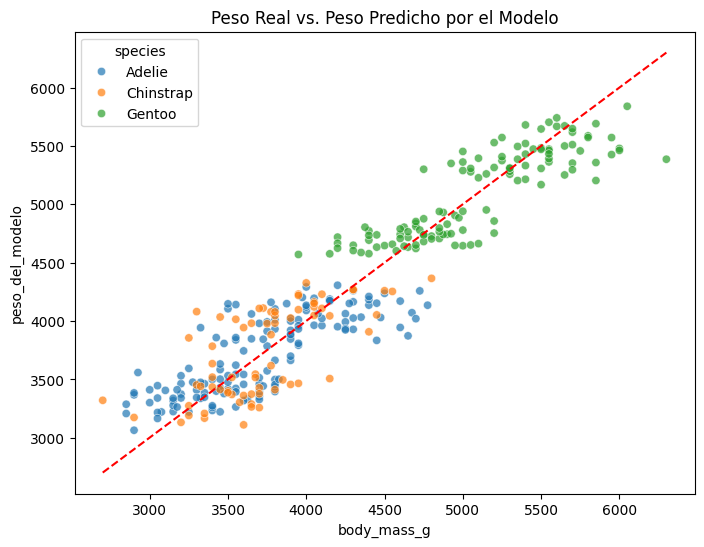

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de Predicción vs. Real

# Este código crea un gráfico de comparación entre los pesos reales y los pesos predichos por un modelo (probablemente de regresión). Es una herramienta común para evaluar qué tan bien funciona un modelo predictivo.

# 1. Configurar el tamaño de la figura
plt.figure(figsize=(8, 6))

# 2. Gráfico de dispersión: compara valores reales vs predichos
sns.scatterplot(
    data=df, 
    x='body_mass_g',      # Valores REALES (observados)
    y='peso_del_modelo',  # Valores PREDICHOS por el modelo
    hue='species',        # Colorear por especie
    alpha=0.7             # Transparencia
)

# 3. Línea de perfección (y = x)
plt.plot(
    [df['body_mass_g'].min(), df['body_mass_g'].max()],  # X: min y max reales
    [df['body_mass_g'].min(), df['body_mass_g'].max()],  # Y: mismos valores
    color='red', 
    linestyle='--'        # Línea punteada roja que representa la predicción perfecta (donde el peso predicho es igual al peso real
)

# 4. Título
plt.title('Peso Real vs. Peso Predicho por el Modelo')
plt.show()

Gentoo (Verde): Forman un grupo claro arriba a la derecha. Son los más pesados y el modelo los identifica perfectamente. Fíjate que hay un punto verde muy a la derecha (un pingüino de >6000g) que el modelo subestimó un poco (predijo ~5500g).

Adelie (Azul) y Chinstrap (Naranja): Están mezclados en la zona de 3000g a 4500g. Esto explica por qué el modelo necesita la variable species; si no la tuviera, no sabría distinguir entre estas dos especies que tienen pesos similares pero quizás proporciones de pico distintas.

Lo Bueno: No veo un "sesgo sistemático". Los puntos no están todos por encima o todos por debajo de la línea; están distribuidos uniformemente.

Lo Curioso: Hay un "hueco" o zona menos poblada entre los 4200g y 4500g. Eso indica que hay una separación natural de tamaños entre los Gentoo y las otras dos especies.

El Outlier: Hay un pingüino (Gentoo) en el extremo derecho (6300g aprox) donde el error fue de casi 800g. Sería interesante revisar en tu df ese registro; podría ser un error de medición o un individuo excepcionalmente grande.

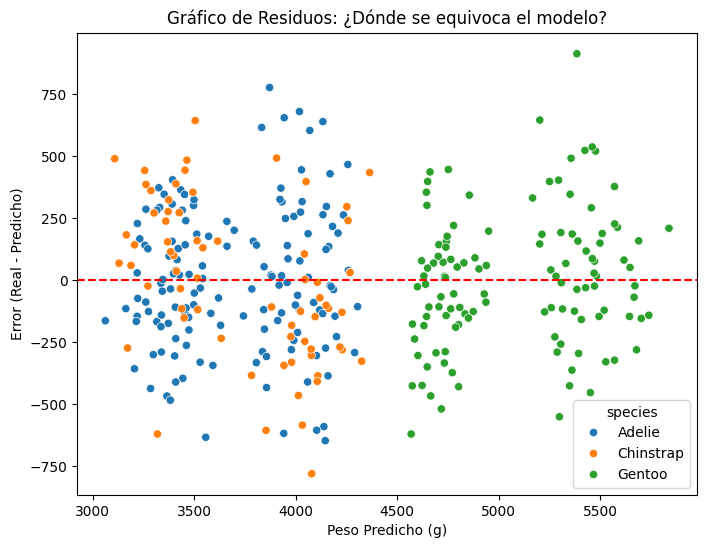

In [ ]:
# Grafico de Residuos: ¿Dónde se equivoca el modelo?

# El gráfico de residuos muestra una distribución aleatoria alrededor de cero, sin patrones evidentes. Esto confirma que los supuestos de la regresión lineal se cumplen y que el modelo no presenta sesgos sistemáticos por especie o tamaño."
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['peso_del_modelo'], y=df['error_del_modelo'], hue=df['species'])
plt.axhline(0, color='red', linestyle='--') # Línea de error cero
plt.title('Gráfico de Residuos: ¿Dónde se equivoca el modelo?')
plt.xlabel('Peso Predicho (g)')
plt.ylabel('Error (Real - Predicho)')
plt.show()

Si el punto está sobre la línea roja: El modelo acertó exactamente.

Si el punto está arriba (positivo): El pingüino real es más pesado de lo que dijo el modelo (el modelo se quedó corto).

Si el punto está abajo (negativo): El pingüino real es más liviano de lo que dijo el modelo (el modelo exageró).

Se ve bastante bien. No hay una forma de "U" o de "S", lo cual es excelente. Significa que tu modelo capturó bien la relación lineal.

Izquierda (Azul/Naranja): Aquí están los Adelie y Chinstrap. El error se mueve mayormente entre -500g y +500g. Es un margen de error aceptable para un animal de 4kg.

Derecha (Verde): Aquí están los Gentoo. Nota que hay un "hueco" en blanco entre los 4300g y 4600g. Esto confirma que los Gentoo son una liga aparte; el modelo no predice pesos en ese rango porque simplemente no hay pingüinos de ese tamaño en tus datos.

Los Outliers (Los "Pingüinos Rebeldes")
Fíjate en el punto verde que está casi en el +1000 arriba a la derecha.

Ese pingüino Gentoo pesaba casi 1 kilo más de lo que sus medidas físicas sugerían. (tambien validar la data real de ese pingüino, por si es un error de medición)

In [99]:
# los mejores modelos fueron:
# model_1_todas_las_especies con R² de 0.92 y sin problemas de multicolinealidad, aunque con más variables y más difícil de interpretar.
# model_1_todas_las_especies_solo_aletas con R² de
# model_1_todas_las_especies_solo_aletas con R² de 0.76 y sin problemas de multicolinealidad, que es más fácil de interpretar y usar en campo, aunque con menor capacidad explicativa. ???

# Matriz de Validación Comparativa. Básicamente, está creando una tabla maestra para poner a competir a todos los modelos entre sí y ver cuál es el que mejor "adivina" la realidad.


# Creamos la tabla comparativa con TUS modelos
models_results = pd.DataFrame(dict(
    actual_value = df.body_mass_g,
    # El modelo más simple (solo aletas)
    pred_solo_aletas = model_1_todas_las_especies_solo_aletas.predict(df).round(2),
    # Tu "Super Modelo" Global (el que llegó al 0.87 de R2)
    pred_global_pro = model_1_todas_las_especies.predict(df).round(2),
    species = df.species,
    sex = df.sex
))
# Calculamos el error absoluto para el mejor modelo
models_results['error_final_solo_aletas'] = (models_results['actual_value'] - models_results['pred_solo_aletas']).abs()
models_results['error_final_global_pro'] = (models_results['actual_value'] - models_results['pred_global_pro']).abs()
models_results.head()


,actual_value,pred_solo_aletas,pred_global_pro,species,sex,error_final_solo_aletas,error_final_global_pro
0,3750.0,3212.26,3784.65,Adelie,Male,537.74,34.65
1,3800.0,3460.68,3394.41,Adelie,Female,339.32,405.59
2,3250.0,3907.85,3592.86,Adelie,Female,657.85,342.86
4,3450.0,3808.48,3582.81,Adelie,Female,358.48,132.81
5,3650.0,3659.43,4059.56,Adelie,Male,9.43,409.56


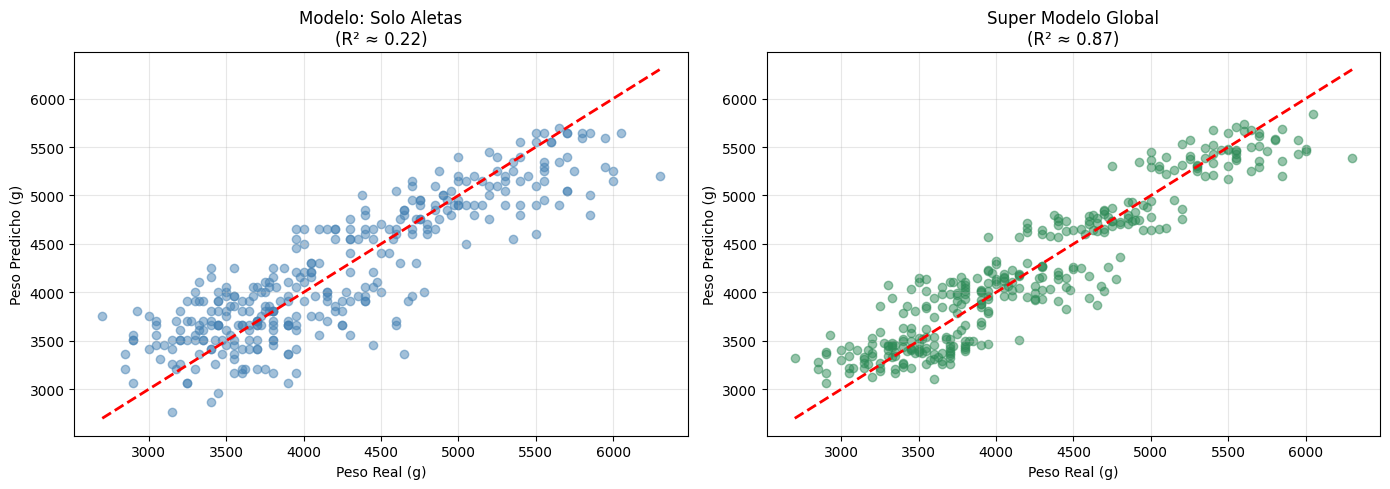

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Modelo 1: Solo aletas (R² bajo)
axes[0].scatter(models_results['actual_value'], 
                models_results['pred_solo_aletas'], 
                alpha=0.5, c='steelblue')
axes[0].plot([models_results['actual_value'].min(), models_results['actual_value'].max()],
             [models_results['actual_value'].min(), models_results['actual_value'].max()],
             'r--', linewidth=2)
axes[0].set_xlabel('Peso Real (g)')
axes[0].set_ylabel('Peso Predicho (g)')
axes[0].set_title('Modelo: Solo Aletas\n(R² ≈ 0.22)')
axes[0].grid(True, alpha=0.3)

# Modelo 2: Super Modelo Global (R² = 0.87)
axes[1].scatter(models_results['actual_value'], 
                models_results['pred_global_pro'], 
                alpha=0.5, c='seagreen')
axes[1].plot([models_results['actual_value'].min(), models_results['actual_value'].max()],
             [models_results['actual_value'].min(), models_results['actual_value'].max()],
             'r--', linewidth=2)
axes[1].set_xlabel('Peso Real (g)')
axes[1].set_ylabel('Peso Predicho (g)')
axes[1].set_title('Super Modelo Global\n(R² ≈ 0.87)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

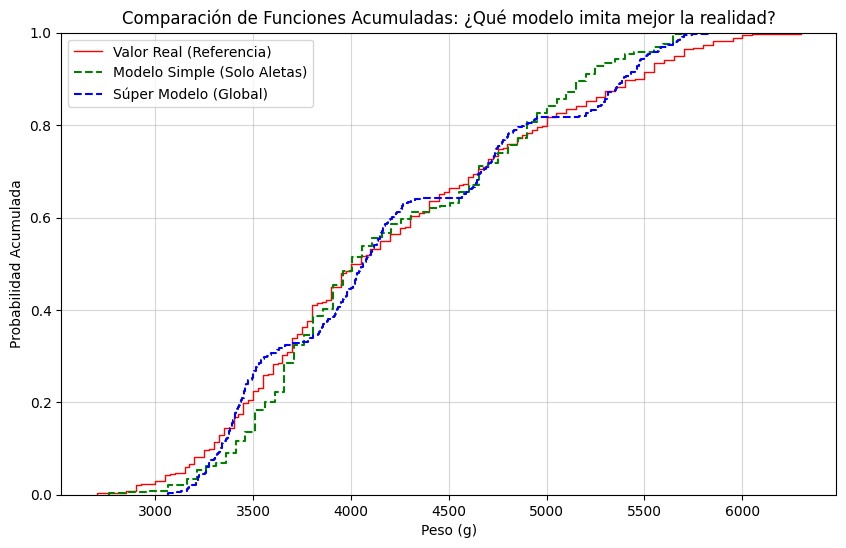

In [116]:
# Función de Probabilidad Acumulada (ECDF - Empirical Cumulative Distribution Function)

# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Graficamos la Realidad (Referencia)
sns.ecdfplot(data=models_results, x='actual_value', label='Valor Real (Referencia)', color='red', linewidth=1)

# Graficamos el Modelo Simple
sns.ecdfplot(data=models_results, x='pred_solo_aletas', label='Modelo Simple (Solo Aletas)', color='green', linestyle='--')

# Graficamos el Súper Modelo Global
sns.ecdfplot(data=models_results, x='pred_global_pro', label='Súper Modelo (Global)', color='blue', linestyle='--')

plt.title('Comparación de Funciones Acumuladas: ¿Qué modelo imita mejor la realidad?')
plt.xlabel('Peso (g)')
plt.ylabel('Probabilidad Acumulada')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

In [108]:
error_max_simple = (models_results['actual_value'] - models_results['pred_solo_aletas']).abs().max()
error_max_global = (models_results['actual_value'] - models_results['pred_global_pro']).abs().max()

print(f"Error máximo Simple: {error_max_simple}g")
print(f"Error máximo Global: {error_max_global}g")

Error máximo Simple: 1288.69g
Error máximo Global: 914.1099999999997g


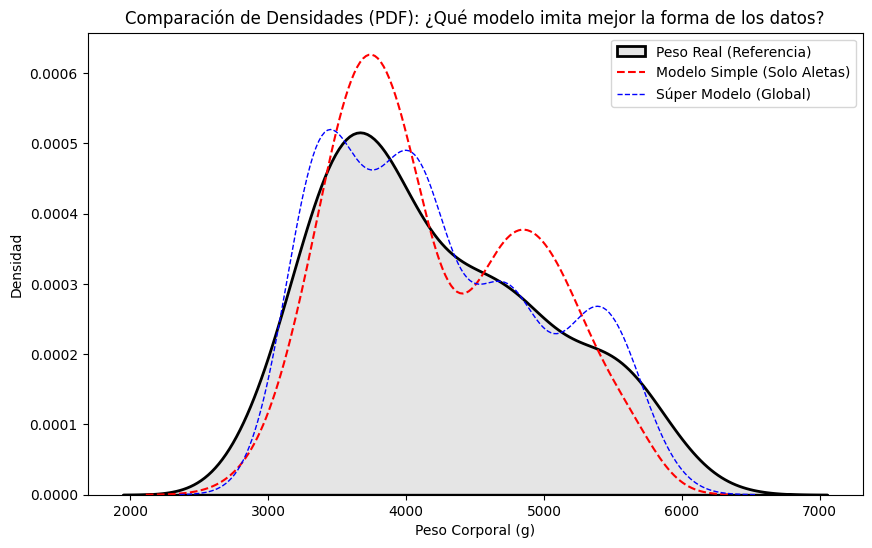

In [ ]:
## Funciones de Densidad de Probabilidad (PDF) ## 

# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. La Realidad (Referencia) - Usamos fill=True para que sea la base
sns.kdeplot(data=models_results, x='actual_value', label='Peso Real (Referencia)', 
            color='black', linewidth=2, fill=True, alpha=0.1)

# 2. Modelo Simple (Solo Aletas)
sns.kdeplot(data=models_results, x='pred_solo_aletas', label='Modelo Simple (Solo Aletas)', 
            color='red', linestyle='--')

# 3. Súper Modelo Global (Pro)
sns.kdeplot(data=models_results, x='pred_global_pro', label='Súper Modelo (Global)', 
            color='blue', linewidth=1, linestyle='--')

plt.title('Comparación de Densidades (PDF): ¿Qué modelo imita mejor la forma de los datos?')
plt.xlabel('Peso Corporal (g)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

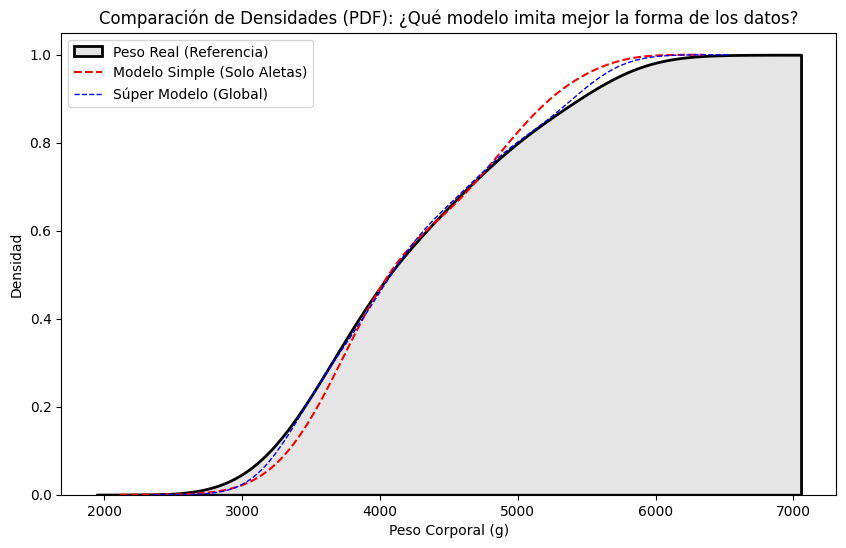

In [ ]:
# cumulative = True // permite graficar la función de distribución acumulada (CDF) en lugar de la función de densidad (PDF). Esto es útil para comparar no solo la forma general de las distribuciones, sino también cómo se acumulan los valores a lo largo del rango de pesos. Al usar cumulative=True, podemos ver claramente qué modelo se acerca más a la distribución real de los datos en términos de acumulación de probabilidades.

## Funciones de Densidad de Probabilidad (PDF) ## 

# import seaborn as sns
# import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. La Realidad (Referencia) - Usamos fill=True para que sea la base
sns.kdeplot(data=models_results, x='actual_value', label='Peso Real (Referencia)', 
            color='black', linewidth=2, fill=True, alpha=0.1, cumulative=True)

# 2. Modelo Simple (Solo Aletas)
sns.kdeplot(data=models_results, x='pred_solo_aletas', label='Modelo Simple (Solo Aletas)', 
            color='red', linestyle='--', cumulative=True)

# 3. Súper Modelo Global (Pro)
sns.kdeplot(data=models_results, x='pred_global_pro', label='Súper Modelo (Global)', 
            color='blue', linewidth=1, linestyle='--', cumulative=True)

plt.title('Comparación de Densidades (PDF): ¿Qué modelo imita mejor la forma de los datos?')
plt.xlabel('Peso Corporal (g)')
plt.ylabel('Densidad')
plt.legend()
plt.show()

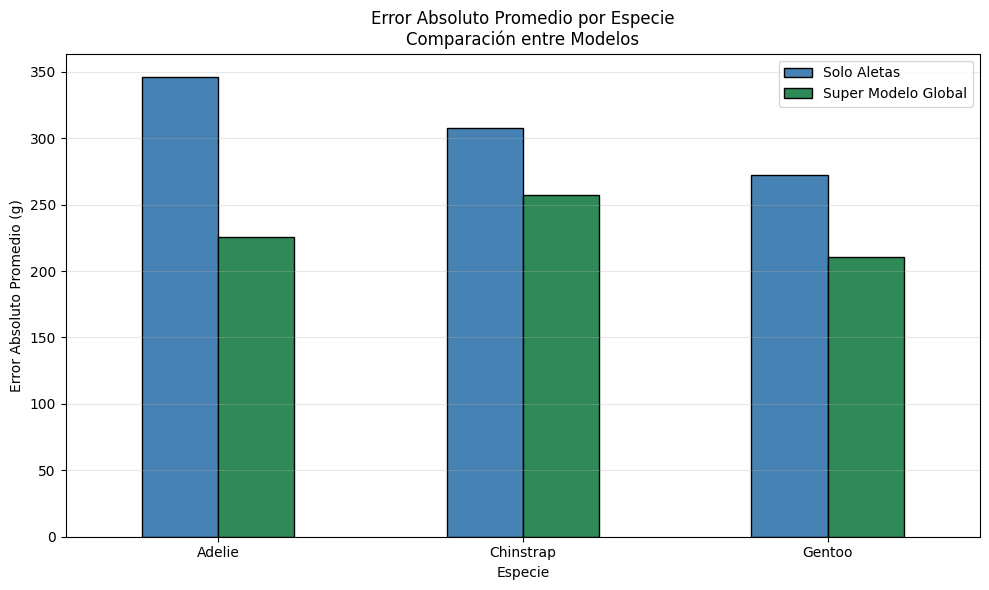

In [103]:
# Calcular error promedio por especie y modelo
error_por_especie = models_results.groupby('species')[['error_final_solo_aletas', 'error_final_global_pro']].mean()

# Gráfico de barras
error_por_especie.plot(kind='bar', figsize=(10, 6), 
                       color=['steelblue', 'seagreen'],
                       edgecolor='black')
plt.title('Error Absoluto Promedio por Especie\nComparación entre Modelos')
plt.ylabel('Error Absoluto Promedio (g)')
plt.xlabel('Especie')
plt.legend(['Solo Aletas', 'Super Modelo Global'])
plt.grid(True, alpha=0.3, axis='y')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

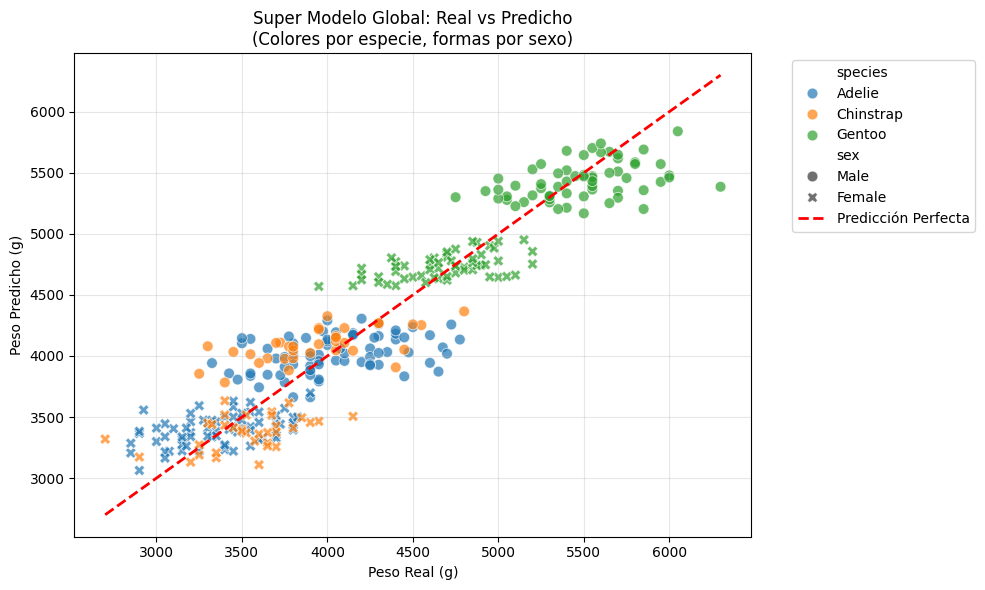

In [105]:
plt.figure(figsize=(10, 6))

# Scatter plot coloreado por especie
sns.scatterplot(data=models_results, 
                x='actual_value', 
                y='pred_global_pro',
                hue='species', 
                style='sex',
                s=60, 
                alpha=0.7)

# Línea de perfección
plt.plot([models_results['actual_value'].min(), models_results['actual_value'].max()],
         [models_results['actual_value'].min(), models_results['actual_value'].max()],
         'r--', linewidth=2, label='Predicción Perfecta')

plt.xlabel('Peso Real (g)')
plt.ylabel('Peso Predicho (g)')
plt.title('Super Modelo Global: Real vs Predicho\n(Colores por especie, formas por sexo)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

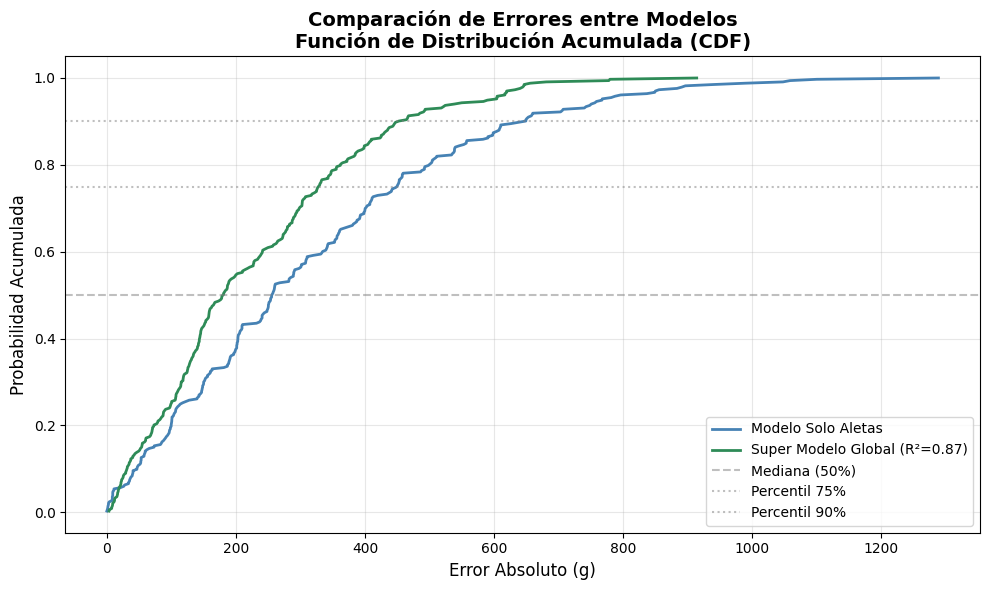

In [106]:

fig, ax = plt.subplots(figsize=(10, 6))

# Calcular CDF para cada modelo
# Ordenar errores y calcular probabilidad acumulada
errores_solo = np.sort(models_results['error_final_solo_aletas'].dropna())
errores_pro = np.sort(models_results['error_final_global_pro'].dropna())

cdf_solo = np.arange(1, len(errores_solo) + 1) / len(errores_solo)
cdf_pro = np.arange(1, len(errores_pro) + 1) / len(errores_pro)

# Graficar CDF
ax.plot(errores_solo, cdf_solo, 
        label='Modelo Solo Aletas', 
        color='steelblue', 
        linewidth=2)

ax.plot(errores_pro, cdf_pro, 
        label='Super Modelo Global (R²=0.87)', 
        color='seagreen', 
        linewidth=2)

# Línea de referencia para percentiles
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Mediana (50%)')
ax.axhline(y=0.75, color='gray', linestyle=':', alpha=0.5, label='Percentil 75%')
ax.axhline(y=0.9, color='gray', linestyle=':', alpha=0.5, label='Percentil 90%')

ax.set_xlabel('Error Absoluto (g)', fontsize=12)
ax.set_ylabel('Probabilidad Acumulada', fontsize=12)
ax.set_title('Comparación de Errores entre Modelos\nFunción de Distribución Acumulada (CDF)', 
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()